# 实验2：数据质量对消费者效益的影响（对应论文图7）

本notebook复现论文图7。

关键设置：
- 5个数据消费者，分别对应不同的 Q 值
- Q 值直接指定为论文中的值：{4.06, 9.53, 7.45, 6.19, 1.98}
- 注意：这里的 Q 值超过了 [0,1] 范围，说明图7中的 Q 是一种不同的定义或经过了缩放。我们忠实于论文数据直接使用这些值。
- 预期结果：高 Q 对应高效益

In [1]:
# ============ 可调参数 ============
Q_VALUES = [4.06, 9.53, 7.45, 6.19, 1.98]   # 论文图7中的5个Q值
N_OWNERS = 5                                   # 数据所有者数量
SEED = 42                                      # 随机种子
P_MAX = 10.0                                   # 最高价格
X_MIN = 0.0                                    # 最小购买量
X_MAX = 15.0                                   # 最大购买量
MU = 0.01                                      # 梯度步长
MAX_ITER = 50                                  # 最大迭代次数
TOL = 1e-6                                     # 收敛阈值

In [2]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from stackelberg_model import run_stackelberg

rng = np.random.RandomState(SEED)
Q = np.array(Q_VALUES)
c = rng.uniform(0.5, 2.0, N_OWNERS)

print('Q values:', Q)
print('Cost values:', c)

result = run_stackelberg(Q, c, p_max=P_MAX, x_min=X_MIN, x_max=X_MAX,
                         mu=MU, max_iter=MAX_ITER, tol=TOL)
print(f'收敛: {result["converged"]}, 迭代次数: {result["iterations"]}')

Q values: [4.06 9.53 7.45 6.19 1.98]
Cost values: [1.06181018 1.92607146 1.59799091 1.39798773 0.73402796]
收敛: False, 迭代次数: 50


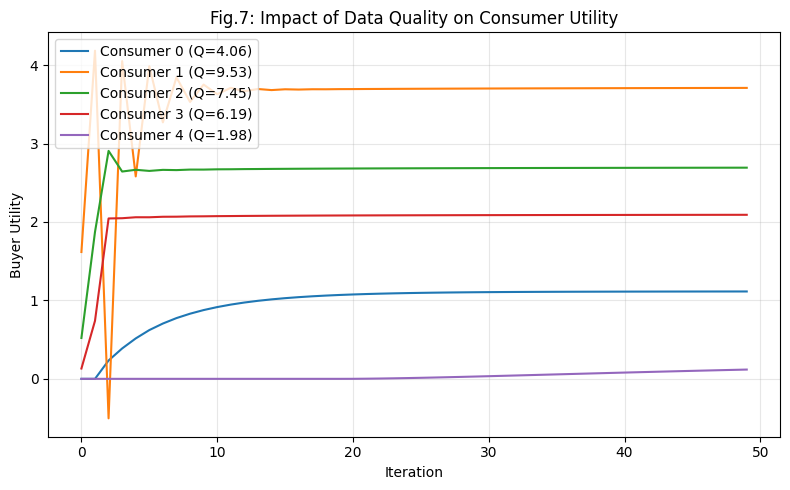

In [3]:
# 图7：不同数据质量对数据消费者效益的影响
fig, ax = plt.subplots(figsize=(8, 5))
iterations = range(len(result['buyer_utility_history']))
for i in range(N_OWNERS):
    ax.plot(iterations, result['buyer_utility_history'][:, i],
            label=f'Consumer {i} (Q={Q_VALUES[i]})')
ax.set_xlabel('Iteration')
ax.set_ylabel('Buyer Utility')
ax.set_title('Fig.7: Impact of Data Quality on Consumer Utility')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()